In [1]:
from __future__ import annotations

from dataclasses import dataclass
from typing import Any, Dict, Optional, Tuple, Union

import numpy as np
from numpy.typing import ArrayLike, NDArray
from scipy import linalg
from sklearn.decomposition import PCA
from sklearn.metrics import pairwise_distances
from sklearn.neighbors import NearestNeighbors


ArrayInput = Union[ArrayLike, NDArray[np.floating]]


@dataclass
class MetricResults:
    fid: float
    kid_mean: float
    kid_std: float
    precision: float
    recall: float
    density: float
    coverage: float

    def to_dict(self) -> Dict[str, float]:
        return {
            "fid": float(self.fid),
            "kid_mean": float(self.kid_mean),
            "kid_std": float(self.kid_std),
            "precision": float(self.precision),
            "recall": float(self.recall),
            "density": float(self.density),
            "coverage": float(self.coverage),
        }


# -----------------------------
# Input / preprocessing helpers
# -----------------------------

def _to_numpy(x: ArrayInput, dtype: np.dtype = np.float64) -> NDArray[np.float64]:
    """Convert numpy / torch / list-like input into a 2D float64 numpy array."""
    if hasattr(x, "detach") and hasattr(x, "cpu"):
        x = x.detach().cpu().numpy()  # torch.Tensor
    arr = np.asarray(x, dtype=dtype)
    if arr.ndim != 2:
        raise ValueError(f"Expected a 2D array of shape [n_samples, n_features], got {arr.shape}.")
    if arr.shape[0] < 2:
        raise ValueError("Need at least 2 samples.")
    if not np.isfinite(arr).all():
        raise ValueError("Input contains NaN or Inf.")
    return arr


def pca_project(
    real_features: ArrayInput,
    fake_features: ArrayInput,
    n_components: int = 50,
    whiten: bool = False,
    random_state: int = 0,
) -> Tuple[NDArray[np.float64], NDArray[np.float64], PCA]:
    """
    Fit PCA on real features only, then transform both real and fake.

    This is often a safer default for scRNA-seq style evaluation, where you want a
    stable shared embedding space and later may replace this with your own pipeline.
    """
    real = _to_numpy(real_features)
    fake = _to_numpy(fake_features)

    n_components = int(min(n_components, real.shape[0], real.shape[1]))
    if n_components < 1:
        raise ValueError("n_components must be >= 1 after clipping.")

    pca = PCA(n_components=n_components, whiten=whiten, random_state=random_state)
    real_proj = pca.fit_transform(real)
    fake_proj = pca.transform(fake)
    return real_proj, fake_proj, pca


# -----------------------------
# FID
# -----------------------------

def _compute_mean_and_cov(features: NDArray[np.float64]) -> Tuple[NDArray[np.float64], NDArray[np.float64]]:
    mu = np.mean(features, axis=0)
    sigma = np.cov(features, rowvar=False)
    sigma = np.atleast_2d(sigma)
    return mu, sigma


def compute_fid(
    real_features: ArrayInput,
    fake_features: ArrayInput,
    eps: float = 1e-6,
) -> float:
    """
    Compute Fréchet Inception Distance on arbitrary feature vectors.

    Note:
      - Despite the name, this implementation works on any embedding matrix, not only
        Inception embeddings.
      - For scRNA-seq, pass PCA/HVG/latent features rather than raw counts if that is
        how your pipeline is defined.
    """
    real = _to_numpy(real_features)
    fake = _to_numpy(fake_features)

    mu1, sigma1 = _compute_mean_and_cov(real)
    mu2, sigma2 = _compute_mean_and_cov(fake)

    diff = mu1 - mu2

    covmean, _ = linalg.sqrtm(sigma1 @ sigma2, disp=False)
    if not np.isfinite(covmean).all():
        offset = np.eye(sigma1.shape[0]) * eps
        covmean = linalg.sqrtm((sigma1 + offset) @ (sigma2 + offset))

    if np.iscomplexobj(covmean):
        covmean = covmean.real

    fid = diff @ diff + np.trace(sigma1) + np.trace(sigma2) - 2.0 * np.trace(covmean)
    return float(np.real(fid))


# -----------------------------
# KID
# -----------------------------

def _polynomial_kernel(
    x: NDArray[np.float64],
    y: NDArray[np.float64],
    degree: int = 3,
    gamma: Optional[float] = None,
    coef0: float = 1.0,
) -> NDArray[np.float64]:
    if gamma is None:
        gamma = 1.0 / x.shape[1]
    return (gamma * (x @ y.T) + coef0) ** degree



def _unbiased_mmd2_from_kernel_matrices(
    k_xx: NDArray[np.float64],
    k_yy: NDArray[np.float64],
    k_xy: NDArray[np.float64],
) -> float:
    m = k_xx.shape[0]
    n = k_yy.shape[0]
    if m < 2 or n < 2:
        raise ValueError("Need at least 2 samples per set for unbiased KID/MMD.")

    sum_xx = (np.sum(k_xx) - np.trace(k_xx)) / (m * (m - 1))
    sum_yy = (np.sum(k_yy) - np.trace(k_yy)) / (n * (n - 1))
    sum_xy = np.sum(k_xy) / (m * n)
    return float(sum_xx + sum_yy - 2.0 * sum_xy)



def compute_kid(
    real_features: ArrayInput,
    fake_features: ArrayInput,
    subset_size: int = 1000,
    n_subsets: int = 100,
    degree: int = 3,
    gamma: Optional[float] = None,
    coef0: float = 1.0,
    random_state: int = 0,
) -> Tuple[float, float]:
    """
    Compute Kernel Inception Distance (KID) mean/std using the unbiased polynomial MMD.

    Returns:
        (kid_mean, kid_std)
    """
    real = _to_numpy(real_features)
    fake = _to_numpy(fake_features)

    rng = np.random.default_rng(random_state)
    m = min(subset_size, real.shape[0], fake.shape[0])
    if m < 2:
        raise ValueError("subset_size is too large for the available samples.")

    estimates = []
    for _ in range(n_subsets):
        real_idx = rng.choice(real.shape[0], size=m, replace=False)
        fake_idx = rng.choice(fake.shape[0], size=m, replace=False)
        x = real[real_idx]
        y = fake[fake_idx]

        k_xx = _polynomial_kernel(x, x, degree=degree, gamma=gamma, coef0=coef0)
        k_yy = _polynomial_kernel(y, y, degree=degree, gamma=gamma, coef0=coef0)
        k_xy = _polynomial_kernel(x, y, degree=degree, gamma=gamma, coef0=coef0)
        estimates.append(_unbiased_mmd2_from_kernel_matrices(k_xx, k_yy, k_xy))

    estimates_arr = np.asarray(estimates, dtype=np.float64)
    return float(estimates_arr.mean()), float(estimates_arr.std(ddof=1) if len(estimates_arr) > 1 else 0.0)


# -----------------------------
# Precision / Recall / Density / Coverage
# -----------------------------

def _get_kth_neighbor_radius(
    features: NDArray[np.float64],
    nearest_k: int,
    metric: str = "euclidean",
) -> NDArray[np.float64]:
    if nearest_k < 1:
        raise ValueError("nearest_k must be >= 1.")
    if features.shape[0] <= nearest_k:
        raise ValueError(
            f"Need more samples than nearest_k. Got n_samples={features.shape[0]}, nearest_k={nearest_k}."
        )

    nn = NearestNeighbors(n_neighbors=nearest_k + 1, metric=metric)
    nn.fit(features)
    distances, _ = nn.kneighbors(features, return_distance=True)
    # The first neighbor is the point itself (distance 0), so use the last column.
    return distances[:, -1]



def compute_prdc(
    real_features: ArrayInput,
    fake_features: ArrayInput,
    nearest_k: int = 5,
    metric: str = "euclidean",
) -> Dict[str, float]:
    """
    Compute precision, recall, density, coverage on arbitrary feature vectors.

    Definitions follow the improved precision/recall family and the PRDC-style density/coverage:
      - precision: fraction of fake samples that fall inside at least one real neighborhood
      - recall: fraction of real samples that fall inside at least one fake neighborhood
      - density: average number of real neighborhoods covering a fake sample, normalized by k
      - coverage: fraction of real samples whose nearest fake is within that real sample's radius
    """
    real = _to_numpy(real_features)
    fake = _to_numpy(fake_features)

    real_radius = _get_kth_neighbor_radius(real, nearest_k=nearest_k, metric=metric)
    fake_radius = _get_kth_neighbor_radius(fake, nearest_k=nearest_k, metric=metric)

    distance_real_fake = pairwise_distances(real, fake, metric=metric)

    precision = np.mean((distance_real_fake < real_radius[:, None]).any(axis=0))
    recall = np.mean((distance_real_fake < fake_radius[None, :]).any(axis=1))
    density = np.mean((distance_real_fake < real_radius[:, None]).sum(axis=0) / nearest_k)
    coverage = np.mean(distance_real_fake.min(axis=1) < real_radius)

    return {
        "precision": float(precision),
        "recall": float(recall),
        "density": float(density),
        "coverage": float(coverage),
    }


# -----------------------------
# All-in-one entrypoint
# -----------------------------

def compute_all_metrics(
    real_features: ArrayInput,
    fake_features: ArrayInput,
    *,
    nearest_k: int = 5,
    kid_subset_size: int = 1000,
    kid_n_subsets: int = 100,
    kid_degree: int = 3,
    kid_gamma: Optional[float] = None,
    kid_coef0: float = 1.0,
    kid_random_state: int = 0,
    metric: str = "euclidean",
) -> MetricResults:
    real = _to_numpy(real_features)
    fake = _to_numpy(fake_features)

    fid = compute_fid(real, fake)
    kid_mean, kid_std = compute_kid(
        real,
        fake,
        subset_size=kid_subset_size,
        n_subsets=kid_n_subsets,
        degree=kid_degree,
        gamma=kid_gamma,
        coef0=kid_coef0,
        random_state=kid_random_state,
    )
    prdc = compute_prdc(real, fake, nearest_k=nearest_k, metric=metric)

    return MetricResults(
        fid=fid,
        kid_mean=kid_mean,
        kid_std=kid_std,
        precision=prdc["precision"],
        recall=prdc["recall"],
        density=prdc["density"],
        coverage=prdc["coverage"],
    )




In [2]:
import numpy as np
import scanpy as sc

# Real data
real_h5ad_path = "/home/suzuki/Projects/scDiffusion/work/20260215_embryonic/data/Embryonic.h5ad"
adata_real = sc.read_h5ad(real_h5ad_path)

# Generated data
sample_path = "/home/suzuki/Projects/scDiffusion/work/20260413_Normalized_Embryonic/20260415_041240_softplus/20260415_044828_sample/SampledData/embryonic.npz"
npz_data = np.load(sample_path, allow_pickle=True)

if "cell_gen" not in npz_data:
    raise KeyError("'cell_gen' key not found in npz file.")

cell_gen = npz_data["cell_gen"]

# real / fake feature matrices
real = adata_real.X
fake = cell_gen

# scipy sparse 対応
if hasattr(real, "toarray"):
    real = real.toarray()

real = np.asarray(real, dtype=np.float64)
fake = np.asarray(fake, dtype=np.float64)

print("real shape:", real.shape)
print("fake shape:", fake.shape)

real shape: (156726, 1024)
fake shape: (10000, 1024)


In [3]:
# PCA なしで
results = compute_all_metrics(real, fake)
print(results.to_dict())

{'fid': 11691.626559138062, 'kid_mean': 49.5336627299041, 'kid_std': 1.1902982921269538, 'precision': 0.0, 'recall': 0.992655972844327, 'density': 0.0, 'coverage': 0.0}


In [4]:
# PCA ありで

# Optional PCA projection step for scRNA-seq-style workflows.
real_proj, fake_proj, _ = pca_project(real, fake, n_components=50)

results = compute_all_metrics(
    real_proj,
    fake_proj,
    nearest_k=5,
    kid_subset_size=1000,
    kid_n_subsets=50,
    metric="euclidean",
)
print(results.to_dict())

{'fid': 2690.3140522165195, 'kid_mean': 93866.18115610996, 'kid_std': 3006.9017427543777, 'precision': 0.0, 'recall': 0.9834041575743655, 'density': 0.0, 'coverage': 0.0}


1. precision = 0.0, density = 0.0
これはめちゃくちゃ強いシグナルです。
意味は：
fake の点が1個も real の近傍に入ってない
= 生成分布が real manifold に全く乗っていない


2. recall ≈ 0.98

一見よさそうに見えるけど、ここは罠です。

recall は

real の点が fake の近傍に入る割合

なので、

fake が広くバラ撒かれてる
or スケールが変（やたら広い）

と、簡単に高くなる

👉 つまり今回の recall は「良い」ではなく
👉 “fake が広すぎるだけ”の可能性が高い

3. coverage = 0.0

これもかなり強い

意味は：

real の点の近くに fake が1つもいない

つまり

👉 局所的には全く一致してない

4. FID が異常に大きい
1024次元: 11691
PCA50: 2690

通常のスケール感だとこれは

👉 分布がかなり離れてる

5. KID が異常値

特に PCA の

kid_mean ≈ 93,000

これは普通じゃないです。

典型原因：

スケーリング不一致
分布のスケールが崩壊
外れ値大量

👉 今回はかなり スケール問題の匂いが強い

In [ ]:
print("real mean:", real.mean(), "std:", real.std())
print("fake mean:", fake.mean(), "std:", fake.std())

real mean: -3.182571315098459e-10 std: 0.9999968091046495
fake mean: -1.4791128469824373 std: 3.9407363290579367


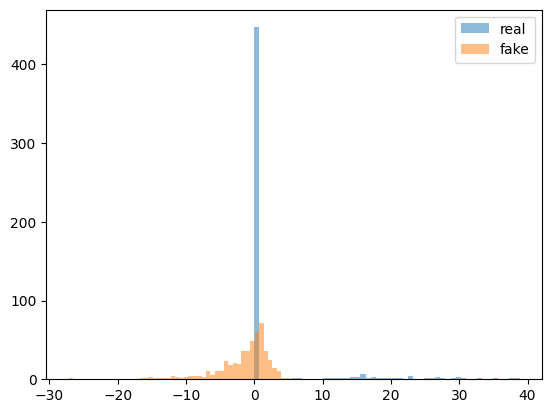

In [11]:
import matplotlib.pyplot as plt

i = 50 # 任意のgene
plt.hist(real[:500, i], bins=50, alpha=0.5, label="real")
plt.hist(fake[:500, i], bins=50, alpha=0.5, label="fake")
plt.legend()
plt.show()

In [10]:
from sklearn.metrics import pairwise_distances

d_rr = pairwise_distances(real[:1000], real[:1000]).mean()
d_rf = pairwise_distances(real[:1000], fake[:1000]).mean()

print("real-real:", d_rr)
print("real-fake:", d_rf)

real-real: 86.67379186269817
real-fake: 154.8349479819264


In [12]:
print("real sparsity:", (real == 0).mean())
print("fake sparsity:", (fake == 0).mean())
eps = 1e-3
print("real near zero:", (np.abs(real) < eps).mean())
print("fake near zero:", (np.abs(fake) < eps).mean())

real sparsity: 0.0
fake sparsity: 0.0
real near zero: 1.476751225067953e-05
fake near zero: 0.0003009765625


In [14]:
real_gene_mean = real.mean(axis=0)
fake_gene_mean = fake.mean(axis=0)

real_gene_std = real.std(axis=0)
fake_gene_std = fake.std(axis=0)

print("mean diff avg:", np.mean(np.abs(real_gene_mean - fake_gene_mean)))
print("std diff avg:", np.mean(np.abs(real_gene_std - fake_gene_std)))

print("real gene mean range:", real_gene_mean.min(), real_gene_mean.max())
print("fake gene mean range:", fake_gene_mean.min(), fake_gene_mean.max())

print("real gene std range:", real_gene_std.min(), real_gene_std.max())
print("fake gene std range:", fake_gene_std.min(), fake_gene_std.max())


real_norm = np.linalg.norm(real, axis=1)
fake_norm = np.linalg.norm(fake, axis=1)

print("real norm mean/std:", real_norm.mean(), real_norm.std())
print("fake norm mean/std:", fake_norm.mean(), fake_norm.std())

mean diff avg: 1.47911284666418
std diff avg: 2.9004407154442493
real gene mean range: -4.288730027259553e-08 2.6628077685743223e-08
fake gene mean range: -2.9672568653348366 -0.046815577096515334
real gene std range: 0.9999967384432771 0.9999968693763689
fake gene std range: 3.239378507801917 4.843986577926635
real norm mean/std: 26.261018143310313 18.28530533334003
fake norm mean/std: 134.1256712307438 12.356949836844088


生成分布は real と同じ空間にいるけど、中心もスケールも丸ごとズレています。しかもそのズレは「少し」ではなく、全遺伝子ほぼ一様にです。

In [15]:
fake_recentered = fake - fake.mean(axis=0, keepdims=True)
fake_rescaled = fake_recentered / (fake.std(axis=0, keepdims=True) + 1e-8)

print("recentered/rescaled fake mean:", fake_rescaled.mean(), "std:", fake_rescaled.std())

results_fixed = compute_all_metrics(real, fake_rescaled)
print(results_fixed.to_dict())

recentered/rescaled fake mean: -1.0928757898653885e-18 std: 0.9999999974256344
{'fid': 134.56032457303354, 'kid_mean': 0.01996884571750567, 'kid_std': 0.021125620273329076, 'precision': 0.0297, 'recall': 0.7265291017444457, 'density': 0.00616, 'coverage': 9.570843382718885e-05}


いい流れでデバッグできてるので、**事実（結果）とそこからの推論を完全に分けて整理**します。
そのままメモやスライドに使える形にしておきます。

---

# 🧪 結果（事実）

## ① 元の評価（1024次元・PCAなし）

```python
fid: 11691.63
kid_mean: 49.53
precision: 0.0
recall: 0.9927
density: 0.0
coverage: 0.0
```

---

## ② PCA 50次元での評価

```python
fid: 2690.31
kid_mean: 93866.18
precision: 0.0
recall: 0.9834
density: 0.0
coverage: 0.0
```

---

## ③ 全体統計（real vs fake）

```python
real mean ≈ 0
real std ≈ 1

fake mean ≈ -1.48
fake std ≈ 3.94
```

---

## ④ 距離スケール

```python
real-real: 86.67
real-fake: 154.83
```

---

## ⑤ sparsity

```python
real sparsity: 0.0
fake sparsity: 0.0

real near zero: 1.47e-05
fake near zero: 3.01e-04
```

---

## ⑥ 遺伝子ごとの統計

```python
mean diff avg: 1.48
std diff avg: 2.90

real gene mean range: ~0
fake gene mean range: [-2.97, -0.046]

real gene std range: ~1
fake gene std range: [3.24, 4.84]
```

---

## ⑦ ベクトルノルム

```python
real norm mean: 26.26
fake norm mean: 134.13
```

---

## ⑧ 再標準化後（recenter + rescale）

```python
fid: 134.56
kid_mean: 0.0199
precision: 0.0297
recall: 0.7265
density: 0.00616
coverage: 9.57e-05
```

---

# 🧠 推論（ここからが重要）

## 🔴 第一段階：スケール崩壊

* fake は real に対して

  * 平均が大きくズレている（≈ -1.5）
  * 分散が約4倍
* 遺伝子ごとにほぼ一様にズレている
* ノルムも約5倍

👉 **global shift + global scale mismatch が発生**

---

## 🔴 第二段階：PRDC が完全崩壊

* precision = 0
* density = 0
* coverage = 0

👉 **fake が real manifold に一切乗っていない**

---

## 🔴 第三段階：recall の誤解

* recall ≈ 0.98 は良さではない
* fake の分布が広すぎるだけ

👉 **“雑にカバーしているだけ”**

---

## 🔴 第四段階：PCAでも改善しない

* PCA後でも precision/density/coverage は 0

👉 **単なる高次元問題ではない**

---

## 🔴 第五段階：再標準化で回復

* FID: 11691 → 134
* KID: 49 → 0.02
* precision: 0 → 0.03

👉 **構造自体はある程度学習できている**

---

## 🔴 第六段階：しかし局所構造は崩壊

再標準化後でも：

* precision 低い（≈ 0.03）
* density ≈ 0
* coverage ≈ 0

👉 **local structure（近傍構造）が再現できていない**

---

## 🔴 第七段階：分布の性質

real:

* 平均0・分散1に標準化された空間
* 非ガウス・多峰・構造あり

fake:

* 平均ズレ・分散膨張
* よりガウス的で滑らか

👉 **distribution shape mismatch**

---

## 🔴 第八段階：問題の分解

今回の問題は2層構造

### Layer 1（実装レベル）

* 出力スケールがズレている
* normalization / inverse transform の不整合

### Layer 2（モデルレベル）

* 局所構造を学習できていない
* correlation / manifold が崩壊

---

## 🔴 第九段階：UMAPとの整合

観察：

> 全体に散るが一部に密集

解釈：

* global structure → ある程度再現
* local structure → 崩壊
* → 密集クラスタ発生

👉 **density ≈ 0 と完全一致**

---

## 🔴 最終結論

### ✔ モデルは完全崩壊ではない

* 再標準化後に分布が近づく

### ❌ しかし実用的には未完成

* fidelity（precision）が低い
* local structure が壊れている

---

## 🎯 一言まとめ

👉 **「座標系はズレており、補正すると“それっぽい”が、局所構造はまだ学習できていない」**

---

必要なら次は：

* 「どの層でスケールがズレてるか特定」
* 「局所構造を改善するための具体的なloss/設計」

まで一気に詰められる 👍


# 最初のモデルのサンプリング結果
/home/suzuki/Projects/scDiffusion/work/20260215_embryonic/20260224_084326_Lamda5

In [16]:
# Generated data
sample_path = "/home/suzuki/Projects/scDiffusion/work/20260215_embryonic/20260224_084326_Lamda5/20260224_095109_sample/SampledData/embryonic.npz"
npz_data = np.load(sample_path, allow_pickle=True)

if "cell_gen" not in npz_data:
    raise KeyError("'cell_gen' key not found in npz file.")

cell_gen = npz_data["cell_gen"]

# real / fake feature matrices
real = adata_real.X
fake = cell_gen

# scipy sparse 対応
if hasattr(real, "toarray"):
    real = real.toarray()

real = np.asarray(real, dtype=np.float64)
fake = np.asarray(fake, dtype=np.float64)

print("real shape:", real.shape)
print("fake shape:", fake.shape)


# PCA なしで
results = compute_all_metrics(real, fake)
print(results.to_dict())


# PCA ありで

# Optional PCA projection step for scRNA-seq-style workflows.
real_proj, fake_proj, _ = pca_project(real, fake, n_components=50)

results = compute_all_metrics(
    real_proj,
    fake_proj,
    nearest_k=5,
    kid_subset_size=1000,
    kid_n_subsets=50,
    metric="euclidean",
)
print(results.to_dict())

print("real mean:", real.mean(), "std:", real.std())
print("fake mean:", fake.mean(), "std:", fake.std())

from sklearn.metrics import pairwise_distances

d_rr = pairwise_distances(real[:1000], real[:1000]).mean()
d_rf = pairwise_distances(real[:1000], fake[:1000]).mean()

print("real-real:", d_rr)
print("real-fake:", d_rf)

print("real sparsity:", (real == 0).mean())
print("fake sparsity:", (fake == 0).mean())
eps = 1e-3
print("real near zero:", (np.abs(real) < eps).mean())
print("fake near zero:", (np.abs(fake) < eps).mean())

real_gene_mean = real.mean(axis=0)
fake_gene_mean = fake.mean(axis=0)

real_gene_std = real.std(axis=0)
fake_gene_std = fake.std(axis=0)

print("mean diff avg:", np.mean(np.abs(real_gene_mean - fake_gene_mean)))
print("std diff avg:", np.mean(np.abs(real_gene_std - fake_gene_std)))

print("real gene mean range:", real_gene_mean.min(), real_gene_mean.max())
print("fake gene mean range:", fake_gene_mean.min(), fake_gene_mean.max())

print("real gene std range:", real_gene_std.min(), real_gene_std.max())
print("fake gene std range:", fake_gene_std.min(), fake_gene_std.max())


real_norm = np.linalg.norm(real, axis=1)
fake_norm = np.linalg.norm(fake, axis=1)

print("real norm mean/std:", real_norm.mean(), real_norm.std())
print("fake norm mean/std:", fake_norm.mean(), fake_norm.std())



fake_recentered = fake - fake.mean(axis=0, keepdims=True)
fake_rescaled = fake_recentered / (fake.std(axis=0, keepdims=True) + 1e-8)

print("recentered/rescaled fake mean:", fake_rescaled.mean(), "std:", fake_rescaled.std())

results_fixed = compute_all_metrics(real, fake_rescaled)
print(results_fixed.to_dict())


real shape: (156726, 1024)
fake shape: (10000, 1024)
{'fid': 307.30280406579345, 'kid_mean': 0.04309320787159626, 'kid_std': 0.02205210145377085, 'precision': 0.2007, 'recall': 0.553169225272131, 'density': 0.052660000000000005, 'coverage': 0.0020673021706672794}
{'fid': 111.08091585390542, 'kid_mean': 84.72211472269885, 'kid_std': 117.24821130840124, 'precision': 0.2709, 'recall': 0.7660311626660541, 'density': 0.124, 'coverage': 0.02998864259918584}
real mean: -3.182571315098459e-10 std: 0.9999968091046495
fake mean: -0.08187361008079873 std: 0.6165028496320939
real-real: 86.67379186269817
real-fake: 71.24432338698955
real sparsity: 0.0
fake sparsity: 0.0
real near zero: 1.476751225067953e-05
fake near zero: 0.00191103515625
mean diff avg: 0.08245473017636379
std diff avg: 0.4334737782230569
real gene mean range: -4.288730027259553e-08 2.6628077685743223e-08
fake gene mean range: -0.1839405253274832 0.08609583511825185
real gene std range: 0.9999967384432771 0.9999968693763689
fake g